# A. Importando bibliotecas

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

# B. BASES

## Base Desmatamento

In [2]:
df_desmat = pd.read_excel('https://github.com/JuPLopez/JL_mba_enap/raw/refs/heads/main/Estatistica_Descritiva/tabela_de_desmatamento_ucs_atualizado_prodes-2023(1).xlsx', skiprows= 1, skipfooter=1)
df_desmat.info(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cnuc                    132 non-null    object 
 1   unidade de conservação  132 non-null    object 
 2   área_ha_uc              132 non-null    float64
 3   Até 2007                132 non-null    float64
 4   2008                    132 non-null    float64
 5   2009                    132 non-null    float64
 6   2010                    132 non-null    float64
 7   2011                    132 non-null    float64
 8   2012                    132 non-null    float64
 9   2013                    132 non-null    float64
 10  2014                    132 non-null    float64
 11  2015                    132 non-null    float64
 12  2016                    132 non-null    float64
 13  2017                    132 non-null    float64
 14  2018                    132 non-null    fl

## Base SAMGe

In [5]:
excel_file = pd.ExcelFile('https://github.com/JuPLopez/JL_mba_enap/raw/refs/heads/main/Estatistica_Descritiva/Dados%20do%20SAMGe_completo.xlsx')
planilhas = excel_file.sheet_names
print("Planilhas encontradas:")
for planilha in planilhas:
    print(f"- {planilha}")

Planilhas encontradas:
- 0 - Atualização
- 1 - Identificação e Resultados
- 2 - Recursos e Valores (RV)
- 3 - Usos
- 4 - Ações
- 5 - Ações x Usos
- 6 - RV x Ações x Usos
- 7 - Processos Prioritários


### SAMGe 1: Identificação e Resultados 

In [6]:
df_samge1 = pd.read_excel('https://github.com/JuPLopez/JL_mba_enap/raw/refs/heads/main/Estatistica_Descritiva/Dados%20do%20SAMGe_completo.xlsx', sheet_name = '1 - Identificação e Resultados')
df_samge1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3638 entries, 0 to 3637
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID Entrada                      3638 non-null   int64  
 1   Ano                             3638 non-null   int64  
 2   Esfera Administrativa           3638 non-null   object 
 3   CNUC                            3638 non-null   object 
 4   Nome da UC                      3638 non-null   object 
 5   Gerência Regional/Órgão Gestor  3638 non-null   object 
 6   NGI                             1422 non-null   object 
 7   UF                              3638 non-null   object 
 8   Municípios Abrangidos           3638 non-null   object 
 9   Latitude                        3566 non-null   float64
 10  Longitude                       3566 non-null   float64
 11  Quem Preenche                   3627 non-null   object 
 12  Plano de Manejo                 36

In [18]:
df_samge1["Ano"].unique()

array([2023, 2022, 2021, 2020, 2019, 2018, 2017], dtype=int64)

## MESCLAR BASES

In [29]:
df_identif = df_samge1[['CNUC', 'UF', 'NGI', "Ano", 'Municípios Abrangidos', 'Plano de Manejo', 'Esfera Administrativa', 'Categoria (Sigla)', 'Grupo (Sigla)', 'Categoria IUCN','Bioma', 'Área Soma Bioma (ha)', 'Ano de Criação', 'Instrumento de Criação']]
df_identif.rename(columns={"Ano": 'AnoSamge_ID', 'CNUC':'cnuc'}, inplace=True)
df_identif = df_identif[df_identif["AnoSamge_ID"] == 2023]
df_identif = df_identif[df_identif["Esfera Administrativa"] == 'Federal'] 

df_baseED = pd.merge(df_desmat, df_identif, on='cnuc', how='outer') 
df_baseED.drop(['TOTAL', 'AnoSamge_ID', 'Esfera Administrativa', 'Área Soma Bioma (ha)', 'Categoria IUCN', 'Instrumento de Criação','Municípios Abrangidos'], axis=1, inplace=True)
#df_baseED['Ano de Criação'] = df_baseED['Ano de Criação'].astype(int)

C:\Users\DELL\AppData\Local\Temp\ipykernel_10288\3977054992.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_identif.rename(columns={"Ano": 'AnoSamge_ID', 'CNUC':'cnuc'}, inplace=True)


In [40]:
# Filtra apenas UCs onde houve desmatamento
df_baseEDdesmat = df_baseED[df_baseED['área_ha_uc'].notna() & (df_baseED['área_ha_uc'] != 0)]
#df_baseEDdesmat = df_baseED['área_ha_uc'].dropna()
#df_baseEDdesmat = df_baseEDdesmat[df_baseEDdesmat != 0]
df_baseEDdesmat.head()

,cnuc,unidade de conservação,área_ha_uc,Até 2007,2008,2009,2010,2011,2012,2013,...,2022,2023,UF,NGI,Plano de Manejo,Categoria (Sigla),Grupo (Sigla),Bioma,Ano de Criação,faixas
0,0000.00.0022,APA do Igarapé Gelado,2.071467e+04,8955.77,119.53,0.00,5.15,0.00,0.00,10.63,...,14.29,0.000000,PA,ICMBio Carajás,Sim,APA,US,Amazônia,1989.0,Entre 1980 e 1989
1,0000.00.0268,APA do Tapajós,2.040336e+06,69935.98,1648.94,1523.54,829.74,1352.57,2238.81,3246.37,...,11140.01,4879.106948,PA,ICMBio Jamanxim,Sem Informação,APA,US,Amazônia,2006.0,Entre 2000 e 2009
2,0000.00.3407,APA dos Campos de Manicoré,1.521325e+05,28.11,0.00,24.53,4.32,16.52,0.00,0.00,...,29.66,1.709380,AM,ICMBio Humaitá,Sem Informação,APA,US,Amazônia,2016.0,Entre 2010 e 2019
3,0000.00.0043,ARIE Projeto Dinâmica Biológica de Fragmento F...,3.336296e+03,74.26,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000000,AM,NaN,Sim,ARIE,US,Amazônia,1985.0,Entre 1980 e 1989
4,0000.00.0044,ARIE Seringal Nova Esperança,2.573984e+03,611.03,13.01,25.32,28.75,34.40,222.00,26.89,...,61.31,90.599129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>


# *Estatística Descritiva*

## Aula 2

### Exercício 2: Exiba as variáveis disponíveis na amostra

In [42]:
df_baseEDdesmat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131 entries, 0 to 131
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cnuc                    131 non-null    object 
 1   unidade de conservação  131 non-null    object 
 2   área_ha_uc              131 non-null    float64
 3   Até 2007                131 non-null    float64
 4   2008                    131 non-null    float64
 5   2009                    131 non-null    float64
 6   2010                    131 non-null    float64
 7   2011                    131 non-null    float64
 8   2012                    131 non-null    float64
 9   2013                    131 non-null    float64
 10  2014                    131 non-null    float64
 11  2015                    131 non-null    float64
 12  2016                    131 non-null    float64
 13  2017                    131 non-null    float64
 14  2018                    131 non-null    float64

### Exercício 3: Identifique o tipo de cada variável
(0) cnuc: variável qualitativa nominal
<br>(1) unidade de conservação: variável qualitativa nominal
<br>(2) área_ha_uc: variável quantivativa contínua
<br>(3) Até 2007, (4) 2008, (5) 2009, (6) 2010, (7) 2011, (8) 2012, (9) 2013, (10) 2014, (11) 2015, 
(12) 2016, (13) 2017, (14) 2018, (15) 2019, (16) 2020, (17) 2021, (18) 2022, (19) 2023: variáveis quantivativas contínuas
<br>(20) UF: variável qualitativa nominal
<br>(21) NGI: variável qualitativa nominal 
<br>(22) Plano de Manejo: variável qualitativa nominal 
<br>(23) Categoria (Sigla): variável qualitativa nominal
<br>(24) Grupo (Sigla): variável qualitativa nominal 
<br>(25) Bioma: variável qualitativa nominal 
<br>(26) Ano de Criação: variável quantitativa discreta

### Exercício 4. Exiba a distribuição de frequência de cada variável

In [43]:
# (2) área_ha_uc: variável quantivativa contínua
df_baseEDdesmat['área_ha_uc'].describe()
#df_baseED.área_ha_uc.value_counts()    

count    1.310000e+02
mean     4.923144e+05
std      6.176022e+05
min      2.573984e+03
25%      1.131172e+05
50%      2.869549e+05
75%      6.719367e+05
max      3.865169e+06
Name: área_ha_uc, dtype: float64

<Axes: >

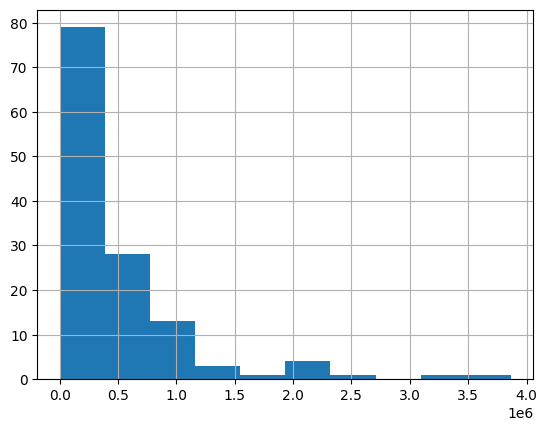

In [45]:
df_baseEDdesmat['área_ha_uc'].hist()

In [46]:
# (3) Até 2007, (4) 2008, (5) 2009, (6) 2010, (7) 2011, (8) 2012, (9) 2013, (10) 2014, (11) 2015, (12) 2016, (13) 2017, (14) 2018, (15) 2019, (16) 2020, (17) 2021, (18) 2022, (19) 2023: variáveis quantivativas contínuas
df_baseEDdesmat[2012].describe()

count     131.000000
mean      147.552595
std       574.932572
min         0.000000
25%         0.000000
50%         0.000000
75%        43.015000
max      5101.720000
Name: 2012, dtype: float64

<Axes: >

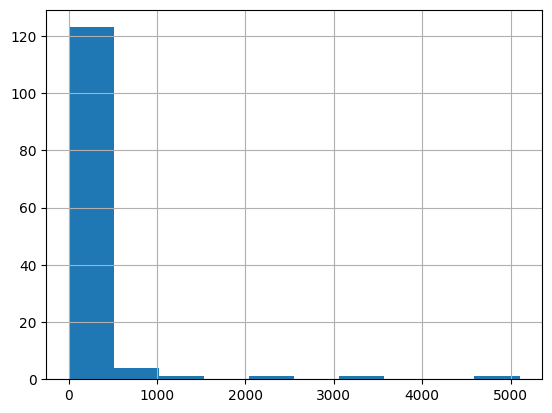

In [47]:
df_baseEDdesmat[2012].hist()

In [48]:
df_baseEDdesmat[2023].describe()

count     131.000000
mean      166.169964
std       579.629893
min         0.000000
25%         0.000000
50%         9.210504
75%        99.201669
max      4879.106948
Name: 2023, dtype: float64

In [21]:
# (20) UF: variável qualitativa nominal
# df_baseED.UF.value_counts() 

In [ ]:
# (21) NGI: variável qualitativa nominal

In [15]:
# (22) Plano de Manejo: variável qualitativa nominal
df_baseED['Plano de Manejo'].value_counts() 

Plano de Manejo
Sim               179
Sem Informação    104
Não                46
Name: count, dtype: int64

In [49]:
# (22) Plano de Manejo: variável qualitativa nominal
df_baseEDdesmat['Plano de Manejo'].value_counts() 


Plano de Manejo
Sim               74
Sem Informação    42
Não               14
Name: count, dtype: int64

In [16]:
# (23) Categoria (Sigla): variável qualitativa nominal
df_baseED['Categoria (Sigla)'].value_counts() 

Categoria (Sigla)
PARNA    74
FLONA    66
RESEX    66
APA      36
REBIO    31
ESEC     30
ARIE     10
RVS       9
MONA      5
RDS       2
Name: count, dtype: int64

In [50]:
df_baseEDdesmat['Categoria (Sigla)'].value_counts() 

Categoria (Sigla)
RESEX    50
FLONA    35
PARNA    21
REBIO    10
ESEC      9
APA       3
ARIE      1
RDS       1
Name: count, dtype: int64

In [17]:
# (24) Grupo (Sigla): variável qualitativa nominal
df_baseED['Grupo (Sigla)'].value_counts()

Grupo (Sigla)
US    180
PI    149
Name: count, dtype: int64

In [56]:
df_baseEDdesmat['Grupo (Sigla)'].value_counts()

Grupo (Sigla)
US    90
PI    40
Name: count, dtype: int64

In [18]:
# (25) Bioma: variável qualitativa nominal
df_baseED['Bioma'].value_counts()

Bioma
Amazônia          130
Mata Atlântica     96
Cerrado            40
Marinho            30
Caatinga           28
Pampa               3
Pantanal            2
Name: count, dtype: int64

In [52]:
df_baseEDdesmat['Bioma'].value_counts()

Bioma
Amazônia    128
Marinho       2
Name: count, dtype: int64

In [55]:
df_filtrado = df_baseEDdesmat[df_baseEDdesmat['Bioma'] == 'Marinho']
df_filtrado

,cnuc,unidade de conservação,área_ha_uc,Até 2007,2008,2009,2010,2011,2012,2013,...,2022,2023,UF,NGI,Plano de Manejo,Categoria (Sigla),Grupo (Sigla),Bioma,Ano de Criação,faixas
81,0000.00.3654,RESEX Arapiranga-Tromaí,186936.309077,2238.67,0.0,0.00,0.0,0.0,9.35,0.0,...,0.0,0.0,MA,ICMBio São Luís,Sem Informação,RESEX,US,Marinho,2018.0,Entre 2010 e 2019
91,0000.00.0279,RESEX de Cururupu,186053.496056,20808.29,26.7,2.32,0.0,0.0,0.00,0.0,...,0.0,0.0,MA,ICMBio São Luís,Sim,RESEX,US,Marinho,2004.0,Entre 2000 e 2009


In [31]:
# (26) Ano de Criação: variável quantitativa discreta
def criacao(x):
  try:
      x = int(x)
  except:
      return pd.NA

  if x<1960: return "Anterior a 1960"
  elif x<1970: return "Entre 1960 e 1969"
  elif x<1980: return "Entre 1970 e 1979"
  elif x<1990: return "Entre 1980 e 1989"
  elif x<2000: return "Entre 1990 e 1999"
  elif x<2010: return "Entre 2000 e 2009"
  elif x<2020: return "Entre 2010 e 2019"
  elif x>=2020: return "POsterior a 2020"

  return pd.NA

df_baseED['faixas'] = df_baseED['Ano de Criação'].apply(criacao);
df_baseED.faixas.value_counts().sort_index()


faixas
Anterior a 1960        6
Entre 1960 e 1969     17
Entre 1970 e 1979     12
Entre 1980 e 1989     84
Entre 1990 e 1999     50
Entre 2000 e 2009    117
Entre 2010 e 2019     41
POsterior a 2020       2
Name: count, dtype: int64

In [53]:
df_baseEDdesmat['faixas'] = df_baseEDdesmat['Ano de Criação'].apply(criacao);
df_baseEDdesmat.faixas.value_counts().sort_index()


C:\Users\DELL\AppData\Local\Temp\ipykernel_10288\3984970645.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_baseEDdesmat['faixas'] = df_baseEDdesmat['Ano de Criação'].apply(criacao);


faixas
Entre 1960 e 1969     3
Entre 1970 e 1979     4
Entre 1980 e 1989    29
Entre 1990 e 1999    18
Entre 2000 e 2009    60
Entre 2010 e 2019    15
POsterior a 2020      1
Name: count, dtype: int64

### Exercício 5. Indique, caso existam, os possíveis desbalanceamentos de sua amostra

### Exercício 6. Escolha uma variável qualitativa nominal e exiba um gráﬁco de setores (pizza)

### Exercício 7. Escolha uma variável quantitativa e exiba um histograma

## Aula 3

### Exercício 1. Escolha uma variável contínua em sua amostra e identiﬁque sua moda, média e mediana.

#### 1.1. Anote no caderno de análise se essas medidas são coincidentes e qual a interpretação associada (tanto para o caso aﬁrmativo, quanto negativo); 

#### 1.2. Identiﬁque também as médias geométrica e harmônica, discorrendo a respeito de qual delas apresenta uma melhor informação acerca da amostra.

### Exercício 2. Exiba um histograma da variável escolhida, acrescentando:
2.1. Uma linha vertical azul para indicar a moda;
<br>2.2. Uma linha vertical verde para marcar a média; 
<br>2.3. E uma linha vertical cinza para indicar a mediana.

### Exercício 3. Escolha uma variável quantitativa em seu dataset e exiba um boxplot. 

#### Identiﬁque a existência, ou não, de outliers
Calcule os valores mínimo e máximo do boxplot e identiﬁque valores abaixo ou acima desses limites; 
<br> Anote suas conclusões;
<br> Compare o primeiro e terceiro quartil de sua amostra, discorra em seu caderno sobre os achados

## Aula 4

### Exercício 1. Selecione uma variável contínua de interesse e 
Calcule todas as medidas de dispersão apresentadas (variância e desvios amostrais, bem como amplitude, intervalo interquartílico, coeﬁciente de dispersão quartílica e coeﬁciente de variação). 

#### Anote em seu caderno a interpretação das medidas obtidas:
1.1. Sua amostra é concentrada ou dispersa?
<br>1.2. A amplitude interna (IIQ) é proporcional à amplitude total da amostra?
<br>1.3. Quais a implicações dessas informações em relação ao contexto/signiﬁcado concreto dessa variável?

### Exercício 2. Exiba um gráﬁco de dispersão (KDE) da variável estudada
2.1. Sinalize os componentes do IIQ (i.e. Q1 e Q3) com linhas verticais na cor cinza;
<br>2.2. Sinalize, com linhas verticais azuis, a média amostral e o primeiro desvio padrão à esquerda e à direita

### Exercício 3. Exiba um gráﬁco KDE, marcando, quando existir, os outliers;

### Exercício 4. Agora, calcule as medidas de assimetria e curtose da variável analisada;
a) Anote em seu caderno as respectivas interpretações das medidas encontradas;
<br> b) Discorra sobre a existência, ou não, de outliers e sobre uma forma de eliminá-los com base nas medidas de dispersão e forma disponíveis;

## Aula 5

###  Exercício 1. Exiba um gráﬁco de dispersão, do tipo KDE, da sua variável contínua, particionado por alguma variável qualitativa.

### Exercício 2. Exiba o gráﬁco de dispersão do tipo scatter plot de duas variáveis, preferencialmente contínuas, da sua amostra;

### Exercício 3. Exiba gráﬁcos do tipo violin e estude a diferença de dispersão entre subclasses da sua amostra.

### Exercício 4. Selecione duas variáveis categóricas e calcule as medidas de associação. 

### Exercício 5. Selecione duas variáveis contínuas e calcule as medidas de covariância e correlação;

## Aula 6

### Exercício 1. Selecione duas variáveis contínuas no seu dataset e 
calcule os parâmetros de uma regressão simples utilizando o os métodos descritos nesta aula (OLS, MLE, Huber, Quantílico).

### Exercício 2. Selecione três variáveis contínuas, de preferência mantendo a mesma variável dependente do exercício anterior, e 
calcule os parâmetros de regressão utilizando os métodos de regressão multivariada apresentados;

###  Exercício 3. Selecione uma série temporal, decomponha e analise os componentes (tendência, sazonalidade e ruído).

### Exercício 4. Exiba a média móvel da sua série;